# 02 — Inversion of synthetic TMI data

Loads the synthetic survey from notebook **01**, rebuilds the same mesh, and runs **smooth (L2)** then **sparse (IRLS)** magnetic susceptibility inversions. Compares recovered models to the known true geology on cross-sections.

**Prerequisite:** run `01_synthetic_model.ipynb` first.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent
SRC = REPO_ROOT / "src"
sys.path.insert(0, str(SRC))
PROCESSED = REPO_ROOT / "data" / "processed"

from synthetic_model import build_synthetic_mesh, build_true_model, plot_ns_cross_section_comparison
from inversion_setup import build_simulation
from forward_sim import build_magnetic_survey
from run_inversion import run_sparse_inversion

from simpeg import data as simpeg_data
from simpeg import directives, inverse_problem, inversion, optimization, regularization, data_misfit


In [12]:
svy_path = PROCESSED / "synthetic_survey.npz"
if not svy_path.exists():
    raise FileNotFoundError("Run 01_synthetic_model.ipynb first to create synthetic_survey.npz.")

raw = np.load(svy_path)
receiver_locs_full = raw["receiver_locations"]
dobs_full = raw["dobs"]
std_full = raw["standard_deviation"]

# Strict χ² target line: phi_d ≈ chifact * N_data (chifact=1 => ~N).
CHIFACT = 1.0

# 8 GB preset (run that reached ~phi_d/target ≈ 1.55 with maxIter 60): stride 2 + 350 m mesh.
station_stride = 2
keep = np.arange(receiver_locs_full.shape[0]) % station_stride == 0
receiver_locs = receiver_locs_full[keep]
dobs = dobs_full[keep]
std = std_full[keep]

mesh = build_synthetic_mesh(core_cell_m=350.0)
chi_true = build_true_model(mesh)
survey = build_magnetic_survey(receiver_locs)

# Use all cells as active to stay compatible with sensitivity-weight updates in SimPEG 0.25.
actind = np.ones(mesh.n_cells, dtype=bool)

simulation = build_simulation(
    mesh,
    survey,
    actind,
    store_sensitivities="disk",
    sensitivity_path=PROCESSED / "sensitivities_inversion_02",
    sensitivity_dtype=np.float32,
)
data_obj = simpeg_data.Data(survey=survey, dobs=dobs, standard_deviation=std)
print("Mesh cells:", mesh.n_cells, "Active cells:", int(actind.sum()), "Data:", dobs.size)
print("Sensitivity storage: DISK (float32)")
print(
    f"station_stride={station_stride}; target phi_d ~ {dobs.size * CHIFACT:.0f} "
    f"(N={dobs.size}, chifact={CHIFACT})"
)


Mafic cells: 220
Felsic cells: 331
Shear cells: 315
Body cell counts: {'mafic': 220, 'felsic': 331, 'shear': 315}
Assigned susceptibilities: {'background': 0.01, 'mafic': 0.05, 'felsic': 0.0001, 'shear': 0.0001}
Mesh cells: 95220 Active cells: 95220 Data: 5101
Sensitivity storage: DISK (float32)
station_stride=2; target phi_d ~ 5101 (N=5101, chifact=1.0)


In [13]:
class TrackObjective(directives.InversionDirective):
    """Record phi_d and phi_m each iteration (for misfit plots)."""

    def __init__(self):
        super().__init__()
        self.phi_d = []
        self.phi_m = []

    def endIter(self):
        m = self.invProb.model
        self.phi_d.append(float(self.invProb.dmisfit(m)))
        self.phi_m.append(float(self.invProb.reg(m)))

# Start near known synthetic background to reduce initial bias.
m0 = np.full(int(actind.sum()), 0.01, dtype=float)
dmis = data_misfit.L2DataMisfit(data=data_obj, simulation=simulation)
reg = regularization.WeightedLeastSquares(mesh, active_cells=actind)

# Balance smoothness so data fit can progress.
reg.alpha_s = 1e-3
reg.alpha_x = 1.0
reg.alpha_y = 1.0
reg.alpha_z = 1.0

opt = optimization.ProjectedGNCG(
    maxIter=100,
    lower=0.0,
    upper=0.2,
    maxIterCG=35,
    tolCG=1e-4,
)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)
track = TrackObjective()

# Skip UpdateSensitivityWeights + BetaEstimate_ByEig on 8 GB (large J'J / eig spike RAM).
phi_d0 = float(inv_prob.dmisfit(m0))
phi_m0 = float(inv_prob.reg(m0))
inv_prob.beta = phi_d0 / max(phi_m0, 1e-30)

directive_list = [
    directives.BetaSchedule(coolingFactor=2.0, coolingRate=1),
    directives.UpdatePreconditioner(),
    directives.TargetMisfit(chifact=CHIFACT),
    track,
]

inv = inversion.BaseInversion(inv_prob, directiveList=directive_list)
m_smooth = inv.run(m0)
phi_d, phi_m = track.phi_d, track.phi_m

target_phi_d = float(dobs.size) * float(CHIFACT)
final_phi_d = float(phi_d[-1]) if len(phi_d) else np.nan
print(f"Final phi_d = {final_phi_d:.2f}; target phi_d ~= {target_phi_d:.2f}")
if np.isfinite(final_phi_d) and final_phi_d > 1.25 * target_phi_d:
    print("WARNING: still underfit (>25% above target). Consider lowering station_stride, refining mesh, or increasing maxIter.")


writing sensitivity to /Users/shawngabriel/Documents/Projects/Magnetic-Susceptibility-Inversion/data/processed/sensitivities_inversion_02/sensitivity.npy


INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.



Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 5101.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  2.94e+00  8.12e+06  5.01e-29  8.12e+06                         0           inf          inf                
   1  2.94e+00  2.96e+05  1.43e+04  3.38e+05    3.94e+01      0      35       7.72e-03     3.41e+05              
   2  1.47e+00  4.85e+04  1.88e+04  7.61e+04    5.00e+01      0      35       5.09e-02     4.07e+05              
   3  7.36e-01  2.35e+04  2.25e+04  4.01e+04    4.91e+01      0      35       1.71e-01     3.52e+05              
   4  3.68e-01  1.75e+04  2.66e+04  2.72e+04    4.87e+01      0      35       3.36e-01     3.07e+05              
   5  1.84e-01  1.32e+04  2.88e+04  1.85e+04    4.79e+01      0      35       3.05e-01 

phi_d / target at final iteration = 1.00


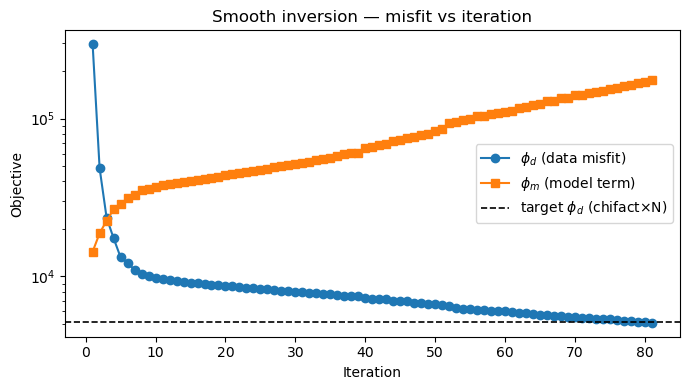

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
it = np.arange(1, len(phi_d) + 1)
target_phi_d = float(dobs.size) * float(CHIFACT)

ax.plot(it, phi_d, "o-", label=r"$\phi_d$ (data misfit)")
ax.plot(it, phi_m, "s-", label=r"$\phi_m$ (model term)")
ax.axhline(target_phi_d, color="k", linestyle="--", linewidth=1.2, label=r"target $\phi_d$ (chifact×N)")

ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.set_title("Smooth inversion — misfit vs iteration")
ax.legend()
ax.set_yscale("log")

if len(phi_d):
    print(f"phi_d / target at final iteration = {phi_d[-1] / target_phi_d:.2f}")

plt.tight_layout()
plt.show()


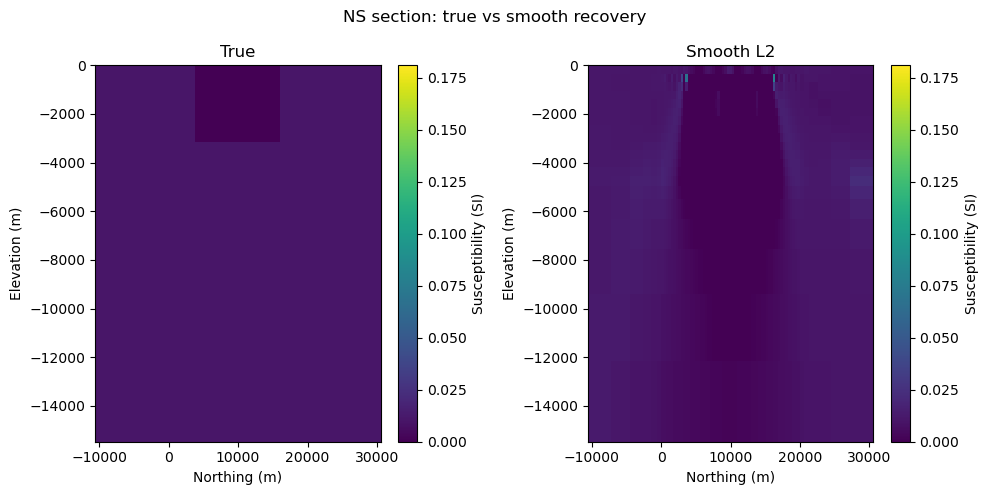

In [15]:
chi_full_smooth = np.zeros(mesh.n_cells, dtype=float)
chi_full_smooth[actind] = m_smooth
plot_ns_cross_section_comparison(
    mesh,
    [chi_true, chi_full_smooth],
    ["True", "Smooth L2"],
    title="NS section: true vs smooth recovery",
)


In [ ]:
m_sparse = run_sparse_inversion(simulation, data_obj, mesh, actind, m0=m_smooth, p_s=0, p_x=1, p_y=1, p_z=1)
chi_full_sparse = np.zeros(mesh.n_cells, dtype=float)
chi_full_sparse[actind] = m_sparse


/opt/miniconda3/envs/eosc454-env/lib/python3.11/site-packages/simpeg/directives/_directives.py:1865: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.save_txt = save_txt
/opt/miniconda3/envs/eosc454-env/lib/python3.11/site-packages/simpeg/directives/_directives.py:1866: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  on_disk = self.save_txt
/opt/miniconda3/envs/eosc454-env/lib/python3.11/site-packages/simpeg/directives/_directives.py:337: UserWarning: Without a Linear preconditioner, convergence may be slow. Consider adding `directives.UpdatePreconditioner` to your directives list
  [directive.validate(self) for directive in self]
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO:


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 5101.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.63e-06  5.08e+03  1.01e+03  5.08e+03                         0           inf          inf                


In [1]:
plot_ns_cross_section_comparison(
    mesh,
    [chi_true, chi_full_smooth, chi_full_sparse],
    ["True", "Smooth L2", "Sparse IRLS"],
    title="NS section: true | smooth | sparse",
)


NameError: name 'plot_ns_cross_section_comparison' is not defined

**Sparse (IRLS) misfit:** `run_sparse_inversion` prints SimPEG iteration tables in the kernel output. For a plotted phi_d/phi_m curve for IRLS, copy the `TrackObjective` pattern from the smooth inversion cell and swap in `regularization.Sparse` plus `Update_IRLS` as in `src/run_inversion.py`.


In [8]:
np.save(PROCESSED / "chi_sparse_synthetic.npy", m_sparse)
np.save(PROCESSED / "chi_smooth_synthetic.npy", m_smooth)
print("Saved sparse/smooth active-cell models to data/processed/")


Saved sparse/smooth active-cell models to data/processed/
